Customer Churn Prediction and Revenue Optimization

Step 1: Data Loading and Quality Checks

In [9]:
#Loading the important libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

<div>
    <h2>Step 1: Data Loading and Quality Checks</h2>
    <p><strong>Objective:</strong> Load the raw dataset, inspect its structure, and ensure correct temporal ordering.</p>
    <ul>
        <li><strong>Loading:</strong> We read <code>data_tp_churn.csv</code> using pandas.</li>
        <li><strong>Quality Check:</strong> We define <code>Period</code> as our time index. It is crucial to sort the data by this column to prevent <em>look-ahead bias</em> (training on future data).</li>
        <li><strong>Missing Values:</strong> We identify columns with missing data (empty strings or NaNs) to handle them in the pipeline.</li>
    </ul>
</div>

In [10]:
#Data Loading 
df = pd.read_csv('data_tp_churn.csv')
df.head()

#Data Cleaning
df = df.replace(r'^\s*$', np.nan, regex=True)#this replaces the empty strings with NaN values (to dont let the code crash)

# Convert numeric columns explicitly
cols_numeric = ['Anciennete', 'Montant_Mensuel', 'Support_Appels']
for col in cols_numeric:
    df[col] = pd.to_numeric(df[col], errors='coerce')#this converts the specified columns to numeric, coercing any non-numeric values to NaN (to avoid errors during analysis)if thre is a typo it will not let machine break

# Sort by Period (CRITICAL for Time Series/Drift)
df = df.sort_values('Periode').reset_index(drop=True)#this will sort the DataFrame by the 'Periode' column in ascending order and reset the index, which is crucial for time series analysis and detecting data drift over time.

# Inspection will help us to understand the data better and to detect any potential issues before we start the analysis. We will check the shape, data types, and missing values in the dataset.
print(f"Shape: {df.shape}")
print("\nTypes:\n", df.dtypes)
print("\nMissing Values:\n", df.isna().sum())
df.head()


Shape: (5000, 6)

Types:
 Periode              int64
Anciennete           int64
Montant_Mensuel    float64
Support_Appels     float64
Contrat                str
Churn                int64
dtype: object

Missing Values:
 Periode              0
Anciennete           0
Montant_Mensuel    670
Support_Appels     493
Contrat              0
Churn                0
dtype: int64


,Periode,Anciennete,Montant_Mensuel,Support_Appels,Contrat,Churn
0,1,7,110.08,1.0,1 an,0
1,1,53,43.69,0.0,Mensuel,1
2,1,36,35.67,0.0,2 ans,0
3,1,47,104.19,NaN,Mensuel,1
4,1,29,24.09,0.0,1 an,0


<div>
    <h2>Step 2: Drift-Oriented EDA</h2>
    <p><strong>Objective:</strong> Highlight non-stationarity and data drift over time.</p>
    <p>We analyze how key statistics evolve across the <code>Periode</code> variable:</p>
    <ol>
        <li><strong>Target Drift:</strong> How does the Churn rate change over time? A rising trend suggests external factors (competitor aggressive pricing).</li>
        <li><strong>Covariate Drift:</strong> Do customer characteristics (e.g., <em>Montant_Mensuel</em>) change? (e.g., inflation or upselling).</li>
        <li><strong>Missingness Shift:</strong> Are we losing data quality over time? This relates to the MNAR (Missing Not At Random) hypothesis.</li>
    </ol>
</div>

C:\Users\AHMAD\AppData\Local\Temp\ipykernel_3580\1725962714.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(['Data Present', 'Data Missing'])


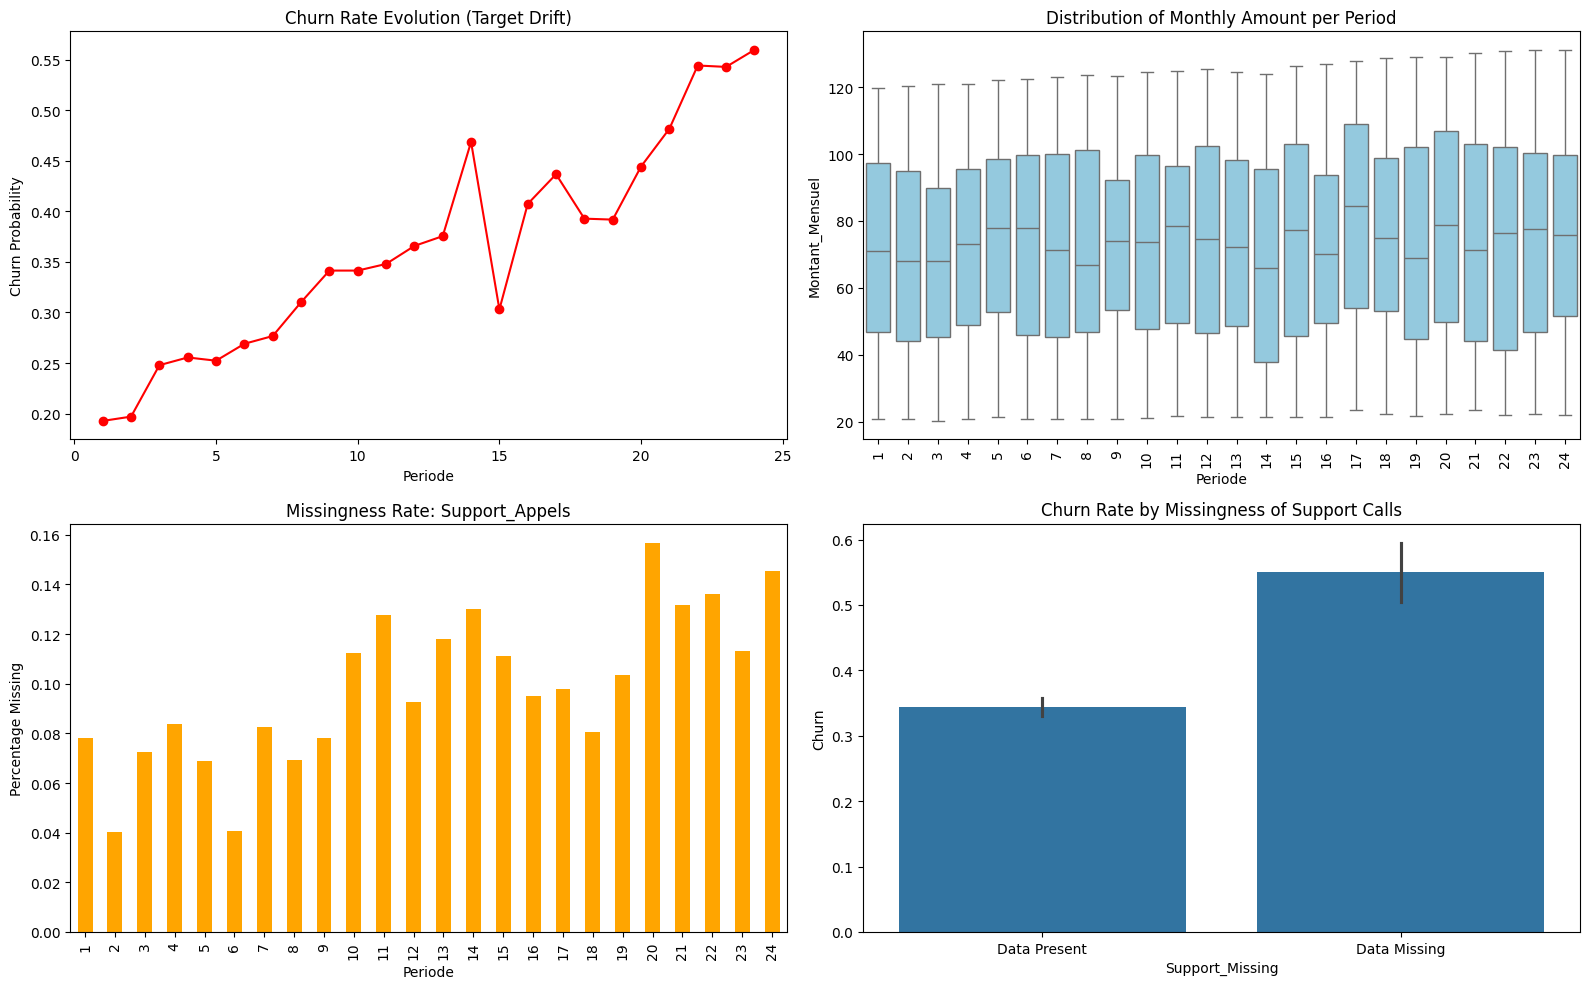

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Churn Rate per Period (Target Drift)
df.groupby('Periode')['Churn'].mean().plot(ax=axes[0,0], marker='o', color='red')
axes[0,0].set_title('Churn Rate Evolution (Target Drift)')
axes[0,0].set_ylabel('Churn Probability')

# 2. Covariate Drift (Montant_Mensuel)
sns.boxplot(x='Periode', y='Montant_Mensuel', data=df, ax=axes[0,1], color='skyblue')
axes[0,1].set_title('Distribution of Monthly Amount per Period')
axes[0,1].tick_params(axis='x', rotation=90)

# 3. Missing Values per Period (Support_Appels is a common culprit)
missing_rate = df.groupby('Periode')['Support_Appels'].apply(lambda x: x.isna().mean())
missing_rate.plot(kind='bar', ax=axes[1,0], color='orange')
axes[1,0].set_title('Missingness Rate: Support_Appels')
axes[1,0].set_ylabel('Percentage Missing')

# 4. Missingness vs Churn (MNAR Check)
# Create a flag for missing support
df['Support_Missing'] = df['Support_Appels'].isna().astype(int)
sns.barplot(x='Support_Missing', y='Churn', data=df, ax=axes[1,1])
axes[1,1].set_title('Churn Rate by Missingness of Support Calls')
axes[1,1].set_xticklabels(['Data Present', 'Data Missing'])

plt.tight_layout()
plt.show()

<div>
    <h2>Step 3: Preprocessing Pipeline</h2>
    <p><strong>Objective:</strong> Create a leakage-free transformation pipeline.</p>
    <p>We use a <code>ColumnTransformer</code> to handle mixed data types without leaking information from the test set (e.g., mean/median is calculated only on training folds):</p>
    <ul>
        <li><strong>Numeric Features:</strong> <em>Anciennete, Montant_Mensuel, Support_Appels</em>.
            <br>Strategy: Simple Imputer (Median) + StandardScaler.</li>
        <li><strong>Categorical Features:</strong> <em>Contrat</em>.
            <br>Strategy: Impute missing with "MISSING" constant + OneHotEncoder.</li>
    </ul>
</div>

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Define Features that we are building the pipeline for
numeric_features = ['Anciennete', 'Montant_Mensuel', 'Support_Appels']
categorical_features = ['Contrat'] 

# Define Transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median') ), #SimpleImputer(strategy='median'): Fills those 670 missing values in Montant_Mensuel using the middle value of the column.
    ('scaler', StandardScaler()) #StandardScaler(): This is Feature Scaling. It centers the data around 0 with a standard deviation of 1. This ensures a feature like "Monthly Amount" (e.g., 100) doesn't overwhelm "Support Calls" (e.g., 2) just because the number is larger.
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='MISSING')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))#OneHotEncoder: Converts text like "Monthly" or "Yearly" into binary columns (0s and 1s). This is necessary because models can't "read" text; they only understand numbers.
])

# Combine into Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Drop auxiliary columns for X
X = df.drop(columns=['Churn', 'Periode', 'Support_Missing']) # Support_Missing was just for EDA
y = df['Churn']
period_col = df['Periode'] # Kept separate for splitting logic

# we used the pipeline to prevent the data leakage,reproducibility,and clean code

<div>
    <h2>Step 4: Logistic Regression Baseline</h2>
    <p><strong>Objective:</strong> Train a linear baseline and monitor performance stability.</p>
    <p>Because the data drifts, a simple 80/20 random split is invalid. We perform a <strong>Time-Series Split</strong> (Expanding Window):</p>
    <ul>
        <li>Train on Periods <code>[0 ... t]</code></li>
        <li>Test on Period <code>[t+1]</code></li>
        <li>Repeat for all available periods.</li>
    </ul>
</div>

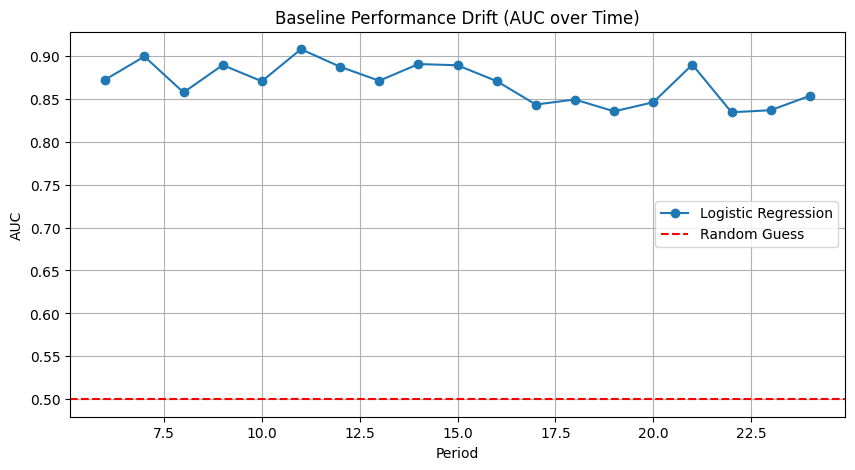

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score

# Baseline Model Pipeline
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

# Simulation of "Production" (Sequential evaluation)
unique_periods = sorted(df['Periode'].unique())
scores_lr = []

# Start training after a few initial periods (e.g., start testing at period 5)
start_period_index = 5

for i in range(start_period_index, len(unique_periods)):
    current_period = unique_periods[i]
    
    # Temporal Split
    train_mask = df['Periode'] < current_period
    test_mask = df['Periode'] == current_period
    
    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]
    
    # Train and Predict
    lr_model.fit(X_train, y_train)
    y_pred_prob = lr_model.predict_proba(X_test)[:, 1]
    
    # Score
    auc = roc_auc_score(y_test, y_pred_prob)#Area Under the ROC Curve (AUC) is a performance metric for classification models.
    #It measures the ability of the model to distinguish between classes. An AUC of 1.0 indicates perfect classification, 
    # while an AUC of 0.5 suggests no discriminative power (equivalent to random guessing).
    #  In this context, we are using AUC to evaluate how well our logistic regression model can predict customer churn over time.
    scores_lr.append({'Period': current_period, 'AUC': auc, 'Model': 'Logistic Regression'})

# Visualization
res_lr = pd.DataFrame(scores_lr)
plt.figure(figsize=(10, 5))
plt.plot(res_lr['Period'], res_lr['AUC'], marker='o', label='Logistic Regression')
plt.axhline(0.5, color='r', linestyle='--', label='Random Guess')
plt.title('Baseline Performance Drift (AUC over Time)')
plt.xlabel('Period')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()

<div >
    <h2>Step 5 & 6: Retraining Strategies & Window Selection</h2>
    <p><strong>Objective:</strong> Determine if "forgetting" old data improves performance.</p>
    <ul>
        <li><strong>Fixed Strategy (Expanding Window):</strong> Train on ALL history <code>[0 ... t]</code>. Good if data is stable.</li>
        <li><strong>Rolling Strategy:</strong> Train only on recent history <code>[t-w ... t]</code> (window size <em>w</em>). Good if concept drift is fast (old data misleads the model).</li>
    </ul>
    <p>We automate the selection of the window size <em>w</em> by backtesting different lengths.</p>
</div>

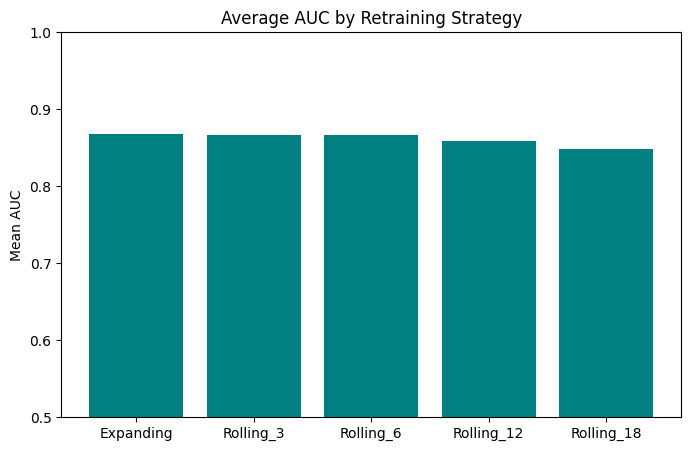

Best Strategy Scores: {'Expanding': np.float64(0.8680930074382597), 'Rolling_3': np.float64(0.8663284695328807), 'Rolling_6': np.float64(0.866679900982342), 'Rolling_12': np.float64(0.8589581241881747), 'Rolling_18': np.float64(0.8486548420773184)}


In [14]:
def backtest_strategy(model, window_size=None):
    """
    If window_size is None, uses Expanding Window (All history).
    If window_size is int, uses Rolling Window (Last w periods).
    """
    scores = []
    
    for i in range(max(start_period_index, window_size or 0), len(unique_periods)):
        current_period = unique_periods[i]
        
        # Define Training Window
        if window_size:
            # Keep only periods between [current - window, current)
            window_start = unique_periods[i - window_size]
            train_mask = (df['Periode'] >= window_start) & (df['Periode'] < current_period)
        else:
            # Expanding: All past
            train_mask = df['Periode'] < current_period
            
        test_mask = df['Periode'] == current_period
        
        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]
        
        if len(y_test) < 2 or len(y_train.unique()) < 2: continue # Skip degenerate cases
            
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_pred)
        scores.append(auc)
        
    return np.mean(scores)

# Compare Expanding vs Rolling Windows
window_candidates = [3, 6, 12, 18]
results_windows = {}

# 1. Evaluate Fixed (Expanding)
results_windows['Expanding'] = backtest_strategy(lr_model, window_size=None)

# 2. Evaluate Rolling Candidates
for w in window_candidates:
    results_windows[f'Rolling_{w}'] = backtest_strategy(lr_model, window_size=w)

# Visualize Best Strategy
plt.figure(figsize=(8, 5))
plt.bar(results_windows.keys(), results_windows.values(), color='teal')
plt.ylim(0.5, 1.0)
plt.title('Average AUC by Retraining Strategy')
plt.ylabel('Mean AUC')
plt.show()

print("Best Strategy Scores:", results_windows)

<div>
    <h2>Step 7: Model Comparison (Random Forest)</h2>
    <p><strong>Objective:</strong> Test if a non-linear model handles the complexity better than Logistic Regression.</p>
    <p>We repeat the sequential evaluation using a Random Forest Classifier. Tree-based models are often more robust to missing values and non-linear interactions but can overfit on small rolling windows.</p>
</div>

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42))
])

# Backtest Random Forest (using the best strategy found in Step 6, e.g., Expanding or best Rolling)
# For demonstration, we'll use Expanding
avg_auc_rf = backtest_strategy(rf_model, window_size=None)

print(f"Logistic Regression (Expanding): {results_windows['Expanding']:.4f}")
print(f"Random Forest (Expanding): {avg_auc_rf:.4f}")

Logistic Regression (Expanding): 0.8681
Random Forest (Expanding): 0.8775


<div >
    <h2>Step 8: Business Optimization</h2>
    <p><strong>Objective:</strong> Optimize the decision threshold based on financial costs.</p>
    <p>AUC is a technical metric. A business metric must account for:</p>
    <ul>
        <li><strong>Cost of False Negative (FN):</strong> We missed a churner. They leave. Cost = Lifetime Value (LTV) lost.</li>
        <li><strong>Cost of False Positive (FP):</strong> We flagged a happy customer. We offer them a discount/gift. Cost = Retention Cost.</li>
    </ul>
    <p><strong>Total Cost</strong> = (FN * LTV) + (FP * Retention Cost)</p>
    <p>We calculate this cost for thresholds varying from 0.0 to 1.0 to find the minimum cost point.</p>
</div>

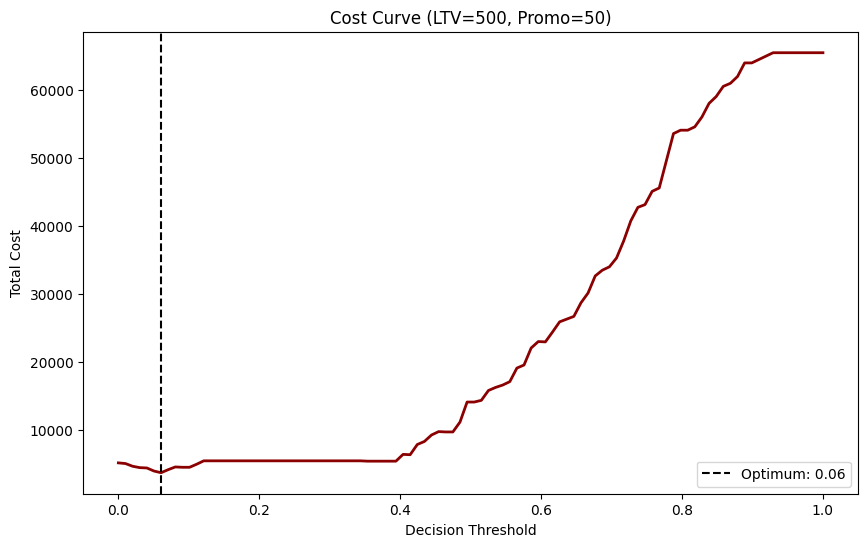

Optimal Decision Threshold: 0.06
Minimum Projected Cost: $3700


In [16]:
def calculate_business_cost(y_true, y_prob, threshold, cost_fn, cost_fp):
    y_pred = (y_prob >= threshold).astype(int)
    # False Negatives: y_true=1, y_pred=0
    fn = ((y_true == 1) & (y_pred == 0)).sum()
    # False Positives: y_true=0, y_pred=1
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    
    return fn * cost_fn + fp * cost_fp

# Example using the last fold's predictions
last_period = unique_periods[-1]
mask_test = df['Periode'] == last_period
X_last = X[mask_test]
y_last = y[mask_test]

# Fit on all previous data
X_prev = X[df['Periode'] < last_period]
y_prev = y[df['Periode'] < last_period]
lr_model.fit(X_prev, y_prev)
y_probs_last = lr_model.predict_proba(X_last)[:, 1]

# Business Assumptions
COST_LTV = 500  # Lost value if customer churns
COST_PROMO = 50 # Cost of retention campaign

thresholds = np.linspace(0, 1, 100)
costs = [calculate_business_cost(y_last, y_probs_last, t, COST_LTV, COST_PROMO) for t in thresholds]

# Plot Cost Curve
plt.figure(figsize=(10, 6))
plt.plot(thresholds, costs, color='darkred', linewidth=2)
plt.title(f'Cost Curve (LTV={COST_LTV}, Promo={COST_PROMO})')
plt.xlabel('Decision Threshold')
plt.ylabel('Total Cost')

# Find Optimal
optimal_idx = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
min_cost = costs[optimal_idx]

plt.axvline(optimal_threshold, color='black', linestyle='--', label=f'Optimum: {optimal_threshold:.2f}')
plt.legend()
plt.show()

print(f"Optimal Decision Threshold: {optimal_threshold:.2f}")
print(f"Minimum Projected Cost: ${min_cost}")